# Pipeline de Mantenimiento Predictivo — NASA CMAPSS FD001

**Autor:** Javier Hortigüela Valiente  
**Máster en Inteligencia Artificial** — Digitech  
**Dataset:** NASA CMAPSS FD001 · **Objetivo:** Predicción de RUL (Remaining Useful Life)

---

### Arquitectura del pipeline

| Etapa | Herramienta | Decisión clave |
|---|---|---|
| Ingestión y EDA | PySpark | Procesamiento escalable con Window functions particionadas |
| Feature Engineering | PySpark Window | Rolling mean/std con w=5 y w=20 por unit_id |
| Entrenamiento | sklearn + XGBoost + MLflow | 5 modelos comparados, NASA Score como criterio |
| Evaluación | NASA Scoring Function asimétrica | Penaliza predicciones optimistas más que pesimistas |
| Despliegue | FastAPI + Pydantic | Validación estricta, healthcheck, Swagger |

> **Métrica principal:** NASA Scoring Function (Saxena et al., 2008) — penaliza exponencialmente los errores optimistas (predecir más vida de la real). El RMSE solo se usa como referencia secundaria.


## 0. Configuración del entorno

Instalación de Java 11 (requerido por la JVM de Spark) y PySpark 3.5.3, única versión compatible con Python 3.12.  
`master='local[*]'` usa todos los cores disponibles de Colab. En producción, este parámetro se sustituye por la URL del cluster (`spark://master:7077` o `yarn`).

In [1]:
import subprocess

# Java
subprocess.run(["apt-get", "install", "-y", "openjdk-11-jdk"], capture_output=True)

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# PySpark 3.5 — única versión que soporta Python 3.12
subprocess.run(["pip", "install", "pyspark==3.5.3", "mlflow", "-q"], capture_output=True)

# Verificar versiones antes de arrancar Spark
import sys
print(f"Python: {sys.version}")

result = subprocess.run(["java", "-version"], capture_output=True, text=True)
print(f"Java: {result.stderr[:50]}")

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TFM_RUL_CMAPSS") \
    .master("local[*]") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark: {spark.version}")
print("OK — entorno listo")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Java: openjdk version "11.0.30" 2026-01-20
OpenJDK Runti
Spark: 3.5.3
OK — entorno listo


## 1. Ingestión de datos

Los ficheros del dataset CMAPSS se descargan directamente desde el repositorio GitHub del proyecto.  
No se requiere Google Drive ni ninguna configuración adicional — el notebook es autocontenido y reproducible en cualquier Colab.

In [ ]:
import subprocess, os

# Descargar dataset NASA CMAPSS FD001 desde el repositorio del proyecto
os.makedirs("/content/data", exist_ok=True)

BASE = "https://raw.githubusercontent.com/lightskinhorti/TFM_CMAPSS-FD001/main/TFM/data"

archivos = ["train_FD001.txt", "test_FD001.txt", "RUL_FD001.txt"]
for fname in archivos:
    result = subprocess.run(
        ["wget", "-q", "-O", f"/content/data/{fname}", f"{BASE}/{fname}"],
        capture_output=True
    )
    size = os.path.getsize(f"/content/data/{fname}")
    print(f"✓ {fname} — {size/1024:.1f} KB")

print("\nDataset listo en /content/data/")

### 1.1 Carga con PySpark

El dataset CMAPSS no tiene cabecera, usa espacios múltiples como separador y tiene 2 columnas vacías al final de cada fila.  
Se define el esquema manualmente y se castea a `Double` — PySpark lee todo como String sin esquema explícito.

In [3]:
# =============================================================
# CARGA DE DATOS — NASA CMAPSS FD001
# =============================================================
# El dataset no tiene cabecera. Las columnas son:
#   - unit_id: identificador del motor (1 a 100 en FD001)
#   - cycle: ciclo de operación (tiempo)
#   - op_setting_1/2/3: condiciones operativas del motor
#   - sensor_1 a sensor_21: mediciones de sensores físicos
# FD001 tiene 2 columnas vacías al final del fichero que
# hay que declarar y eliminar para que el parser no falle.
# =============================================================

col_names = (
    ["unit_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"] +
    [f"sensor_{i}" for i in range(1, 22)]
)

# Columnas auxiliares para absorber los espacios vacíos finales
all_cols = col_names + ["_drop1", "_drop2"]

# --- Carga del conjunto de entrenamiento ---
# Trayectorias completas desde ciclo 1 hasta el fallo del motor.
# Usamos estas trayectorias para calcular el RUL real como target.
train_raw = spark.read \
    .option("sep", " ") \
    .option("header", False) \
    .option("ignoreLeadingWhiteSpace", True) \
    .option("ignoreTrailingWhiteSpace", True) \
    .csv("/content/data/train_FD001.txt") \
    .toDF(*all_cols) \
    .drop("_drop1", "_drop2")

# --- Carga del conjunto de test ---
# Trayectorias truncadas: no llegan hasta el fallo.
# El RUL real en el último ciclo de cada motor está en RUL_FD001.txt
test_raw = spark.read \
    .option("sep", " ") \
    .option("header", False) \
    .option("ignoreLeadingWhiteSpace", True) \
    .option("ignoreTrailingWhiteSpace", True) \
    .csv("/content/data/test_FD001.txt") \
    .toDF(*all_cols) \
    .drop("_drop1", "_drop2")

# --- Casteo a tipo numérico ---
# El parser de Spark lee todo como String por defecto.
# Casteamos cada columna a Double para poder operar sobre ellas.
from pyspark.sql.functions import col

for c in col_names:
    train_raw = train_raw.withColumn(c, col(c).cast("double"))
    test_raw  = test_raw.withColumn(c, col(c).cast("double"))

# --- Verificación ---
print(f"Train — filas: {train_raw.count()}, columnas: {len(train_raw.columns)}")
print(f"Test  — filas: {test_raw.count()},  columnas: {len(test_raw.columns)}")
train_raw.show(5)

Train — filas: 20631, columnas: 26
Test  — filas: 13096,  columnas: 26
+-------+-----+------------+------------+------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|unit_id|cycle|op_setting_1|op_setting_2|op_setting_3|sensor_1|sensor_2|sensor_3|sensor_4|sensor_5|sensor_6|sensor_7|sensor_8|sensor_9|sensor_10|sensor_11|sensor_12|sensor_13|sensor_14|sensor_15|sensor_16|sensor_17|sensor_18|sensor_19|sensor_20|sensor_21|
+-------+-----+------------+------------+------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|    1.0|  1.0|     -7.0E-4|     -4.0E-4|       100.0|  518.67|  641.82|  1589.7|  1400.6|   14.62|   21.61|  554.36| 2388.06| 9046.19|      1.3|    47.47|   521

## 2. Construcción del target RUL

`RUL = max_cycle_del_motor − cycle_actual`

Se calcula con `Window.partitionBy('unit_id')` — cada motor tiene su propio ciclo máximo.

**RUL clipping a 125 ciclos:** en los primeros ciclos de vida el motor opera en condiciones nominales y los sensores no muestran degradación.  
Clipar a 125 concentra la capacidad predictiva del modelo en la zona donde realmente ocurre la degradación (Heimes, 2008).

In [4]:
# =============================================================
# CONSTRUCCIÓN DE LA COLUMNA RUL (Remaining Useful Life)
# =============================================================
# En el conjunto de entrenamiento las trayectorias llegan hasta
# el fallo del motor, por lo que podemos calcular el RUL real
# de cada fila como:
#   RUL = max_cycle_del_motor - cycle_actual
#
# Ejemplo: si un motor falla en el ciclo 200 y estamos en el
# ciclo 50, le quedan 150 ciclos → RUL = 150.
#
# RUL CLIPPING a 125:
# Al inicio de la vida del motor los sensores no muestran
# degradación clara — el motor se comporta igual en el ciclo 1
# que en el ciclo 80. Incluir ese tramo como señal de
# degradación introduce ruido en el modelo.
# Convención estándar en la literatura (Heimes, 2008):
# clipar el RUL máximo a 125 ciclos. Todo RUL > 125 se trata
# como 125 — el modelo aprende a predecir "todavía lejos del
# fallo" sin distinguir entre 130 y 200 ciclos.
# =============================================================

from pyspark.sql import Window
from pyspark.sql.functions import max as spark_max, least, lit

# Ventana particionada por motor: calcula el ciclo máximo
# de cada unidad de forma independiente
window_unit = Window.partitionBy("unit_id")

train_rul = train_raw \
    .withColumn(
        "max_cycle",
        spark_max("cycle").over(window_unit)          # ciclo de fallo de cada motor
    ) \
    .withColumn(
        "RUL_raw",
        (col("max_cycle") - col("cycle")).cast("double")  # RUL sin clipar
    ) \
    .withColumn(
        "RUL",
        least(col("RUL_raw"), lit(125.0))             # RUL clipeado a 125
    ) \
    .drop("max_cycle", "RUL_raw")                     # columnas auxiliares, no necesarias

# --- Verificación ---
# Comprobamos que el motor 1 empieza con RUL=125 (clipeado)
# y termina en RUL=0 (ciclo de fallo)
print("Primeros 5 ciclos del motor 1:")
train_rul.filter(col("unit_id") == 1) \
         .select("unit_id", "cycle", "RUL") \
         .orderBy("cycle") \
         .show(5)

print("Últimos 5 ciclos del motor 1:")
train_rul.filter(col("unit_id") == 1) \
         .select("unit_id", "cycle", "RUL") \
         .orderBy(col("cycle").desc()) \
         .show(5)

print(f"Filas totales tras añadir RUL: {train_rul.count()}")

Primeros 5 ciclos del motor 1:
+-------+-----+-----+
|unit_id|cycle|  RUL|
+-------+-----+-----+
|    1.0|  1.0|125.0|
|    1.0|  2.0|125.0|
|    1.0|  3.0|125.0|
|    1.0|  4.0|125.0|
|    1.0|  5.0|125.0|
+-------+-----+-----+
only showing top 5 rows

Últimos 5 ciclos del motor 1:
+-------+-----+---+
|unit_id|cycle|RUL|
+-------+-----+---+
|    1.0|192.0|0.0|
|    1.0|191.0|1.0|
|    1.0|190.0|2.0|
|    1.0|189.0|3.0|
|    1.0|188.0|4.0|
+-------+-----+---+
only showing top 5 rows

Filas totales tras añadir RUL: 20631


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Identificación de sensores sin varianza

En FD001 (condición operativa única), varios sensores permanecen constantes durante toda la vida del motor — no aportan señal de degradación.  
**Criterio de descarte:** varianza < 0.01 sobre el conjunto de entrenamiento completo.

In [5]:
# =============================================================
# EDA — PASO 1: IDENTIFICACIÓN DE SENSORES MUERTOS
# =============================================================
# Algunos sensores del dataset tienen varianza prácticamente
# nula — su valor no cambia a lo largo de la vida del motor.
# Un sensor que no varía no aporta información sobre la
# degradación del motor y añade ruido al modelo.
# Los eliminamos antes de cualquier análisis posterior.
# =============================================================

from pyspark.sql.functions import variance

sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

# Calcular varianza de cada sensor sobre todo el train set
varianzas = {}
for c in sensor_cols:
    v = train_rul.agg(variance(col(c))).first()[0]
    varianzas[c] = round(v, 6) if v is not None else 0.0

# Separar sensores útiles de sensores muertos
UMBRAL_VARIANZA = 0.01  # sensores con varianza menor a esto se descartan
sensores_muertos  = [c for c, v in varianzas.items() if v < UMBRAL_VARIANZA]
sensores_utiles   = [c for c, v in varianzas.items() if v >= UMBRAL_VARIANZA]

print("=== VARIANZA POR SENSOR ===")
for c, v in sorted(varianzas.items(), key=lambda x: x[1]):
    estado = "DESCARTADO" if v < UMBRAL_VARIANZA else "OK"
    print(f"  {c:<12} varianza = {v:>12.6f}  [{estado}]")

print(f"\nSensores descartados ({len(sensores_muertos)}): {sensores_muertos}")
print(f"Sensores útiles     ({len(sensores_utiles)}): {sensores_utiles}")

=== VARIANZA POR SENSOR ===
  sensor_1     varianza =     0.000000  [DESCARTADO]
  sensor_5     varianza =     0.000000  [DESCARTADO]
  sensor_10    varianza =     0.000000  [DESCARTADO]
  sensor_16    varianza =     0.000000  [DESCARTADO]
  sensor_18    varianza =     0.000000  [DESCARTADO]
  sensor_19    varianza =     0.000000  [DESCARTADO]
  sensor_6     varianza =     0.000002  [DESCARTADO]
  sensor_15    varianza =     0.001407  [DESCARTADO]
  sensor_8     varianza =     0.005039  [DESCARTADO]
  sensor_13    varianza =     0.005172  [DESCARTADO]
  sensor_21    varianza =     0.011718  [OK]
  sensor_20    varianza =     0.032669  [OK]
  sensor_11    varianza =     0.071336  [OK]
  sensor_2     varianza =     0.250053  [OK]
  sensor_12    varianza =     0.543985  [OK]
  sensor_7     varianza =     0.783388  [OK]
  sensor_17    varianza =     2.398667  [OK]
  sensor_3     varianza =    37.590994  [OK]
  sensor_4     varianza =    81.010886  [OK]
  sensor_14    varianza =   363.90049

### 3.2 Filtrado y conversión a pandas para visualización

In [6]:
# =============================================================
# EDA — PASO 2: FILTRADO Y CONVERSIÓN A PANDAS
# =============================================================
# Eliminamos los sensores muertos del DataFrame de PySpark.
# Para las visualizaciones convertimos a pandas — Matplotlib
# no trabaja directamente con DataFrames de Spark.
# Usamos una muestra de 5 motores para que los plots sean
# legibles (con 100 motores se solapan las líneas).
# =============================================================

# Columnas que mantenemos: metadatos + sensores útiles + RUL
cols_finales = ["unit_id", "cycle"] + sensores_utiles + ["RUL"]
train_filtrado = train_rul.select(cols_finales)

print(f"Columnas tras eliminar sensores muertos: {len(train_filtrado.columns)}")

# Conversión a pandas para visualización
# Filtramos solo los motores 1-5 para los plots de trayectoria
train_pd = train_filtrado.filter(col("unit_id") <= 5).toPandas()

print(f"Filas en la muestra pandas (motores 1-5): {len(train_pd)}")
train_pd.head()

Columnas tras eliminar sensores muertos: 14
Filas en la muestra pandas (motores 1-5): 1116


,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_14,sensor_17,sensor_20,sensor_21,RUL
0,1.0,1.0,641.82,1589.70,1400.60,554.36,9046.19,47.47,521.66,8138.62,392.0,39.06,23.4190,125.0
1,1.0,2.0,642.15,1591.82,1403.14,553.75,9044.07,47.49,522.28,8131.49,392.0,39.00,23.4236,125.0
2,1.0,3.0,642.35,1587.99,1404.20,554.26,9052.94,47.27,522.42,8133.23,390.0,38.95,23.3442,125.0
3,1.0,4.0,642.35,1582.79,1401.87,554.45,9049.48,47.13,522.86,8133.83,392.0,38.88,23.3739,125.0
4,1.0,5.0,642.37,1582.85,1406.22,554.00,9055.15,47.28,522.19,8133.80,393.0,38.90,23.4044,125.0


### 3.3 Visualizaciones

Tres gráficas que documentan el estado del dataset antes del modelado:
1. **Trayectorias de degradación** — confirma tendencia progresiva con ruido de alta frecuencia → motiva las rolling windows
2. **Distribución del RUL clipeado** — pico en 125 ciclos corresponde a la fase nominal
3. **Correlación sensor-RUL** — identifica los sensores más predictivos (sensor_11, sensor_4, sensor_12, sensor_7)

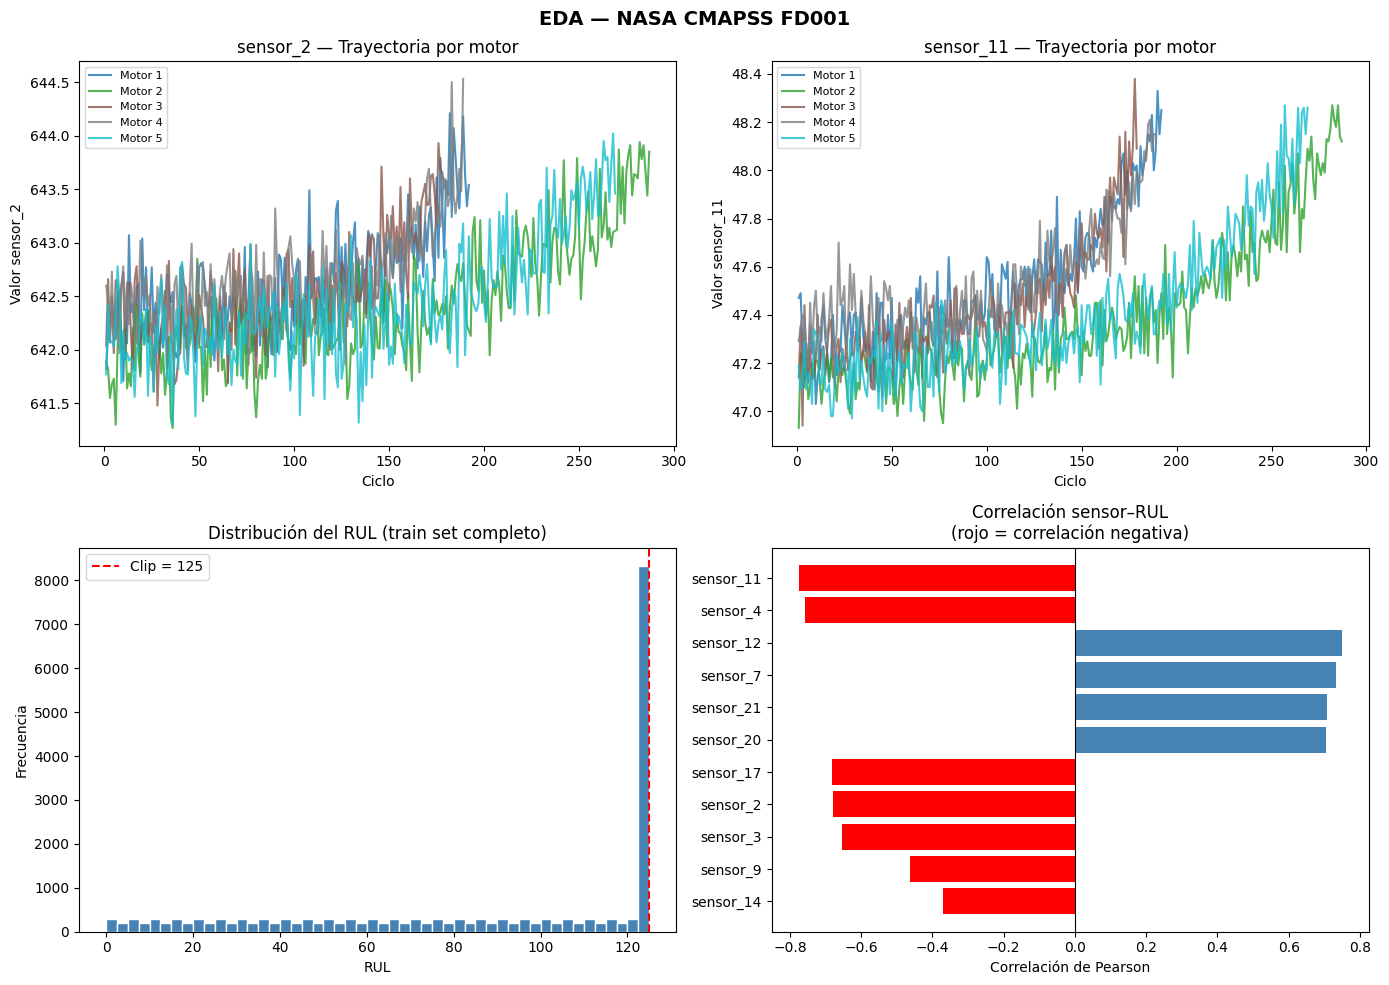

Gráfica guardada en Drive.


In [7]:
# =============================================================
# EDA — PASO 3: VISUALIZACIONES
# =============================================================
# Tres gráficas que van al PDF:
#   1. Trayectorias de degradación de 2 sensores clave
#   2. Distribución del RUL clipeado en el train set
#   3. Correlación de cada sensor con el RUL
# =============================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — NASA CMAPSS FD001", fontsize=14, fontweight="bold")
colores = cm.tab10(np.linspace(0, 1, 5))

# --- Gráfica 1: Trayectoria sensor_2 (temperatura) por motor ---
# sensor_2 es uno de los más correlacionados con degradación
ax = axes[0, 0]
for i, (motor, grupo) in enumerate(train_pd.groupby("unit_id")):
    ax.plot(grupo["cycle"], grupo["sensor_2"],
            color=colores[i], alpha=0.8, label=f"Motor {int(motor)}")
ax.set_title("sensor_2 — Trayectoria por motor")
ax.set_xlabel("Ciclo")
ax.set_ylabel("Valor sensor_2")
ax.legend(fontsize=8)

# --- Gráfica 2: Trayectoria sensor_11 por motor ---
ax = axes[0, 1]
for i, (motor, grupo) in enumerate(train_pd.groupby("unit_id")):
    ax.plot(grupo["cycle"], grupo["sensor_11"],
            color=colores[i], alpha=0.8, label=f"Motor {int(motor)}")
ax.set_title("sensor_11 — Trayectoria por motor")
ax.set_xlabel("Ciclo")
ax.set_ylabel("Valor sensor_11")
ax.legend(fontsize=8)

# --- Gráfica 3: Distribución del RUL clipeado (todos los motores) ---
train_rul_pd = train_rul.select("RUL").toPandas()
ax = axes[1, 0]
ax.hist(train_rul_pd["RUL"], bins=50, color="steelblue", edgecolor="white")
ax.axvline(x=125, color="red", linestyle="--", label="Clip = 125")
ax.set_title("Distribución del RUL (train set completo)")
ax.set_xlabel("RUL")
ax.set_ylabel("Frecuencia")
ax.legend()

# --- Gráfica 4: Correlación sensor-RUL ---
# Correlación de Pearson entre cada sensor útil y el RUL
# Un valor cercano a -1 significa que el sensor sube cuando el RUL baja
# (indicador claro de degradación)
train_corr_pd = train_filtrado.toPandas()
correlaciones = train_corr_pd[sensores_utiles + ["RUL"]].corr()["RUL"].drop("RUL")
correlaciones_sorted = correlaciones.abs().sort_values(ascending=True)

ax = axes[1, 1]
colores_barras = ["red" if correlaciones[s] < 0 else "steelblue"
                  for s in correlaciones_sorted.index]
ax.barh(correlaciones_sorted.index,
        [correlaciones[s] for s in correlaciones_sorted.index],
        color=colores_barras)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Correlación sensor–RUL\n(rojo = correlación negativa)")
ax.set_xlabel("Correlación de Pearson")

plt.tight_layout()
plt.savefig("/content/EDA_plots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada en Drive.")

## 4. Feature Engineering — Rolling Windows

**Por qué rolling windows y no valores raw:**
- Los sensores tienen ruido ciclo a ciclo que enmascara la tendencia de degradación
- Un único valor no captura si la tendencia lleva 5 o 50 ciclos

**Ventana corta (w=5):** reacciona rápido a cambios recientes, sensible al ruido  
**Ventana larga (w=20):** captura la tendencia sostenida, filtra ruido de alta frecuencia

La clave técnica es `partitionBy('unit_id')`: la ventana del motor 1 nunca incluye datos del motor 2.  
Resultado: **55 features** (11 sensores × 5 estadísticos: raw, mean5, std5, mean20, std20)

In [8]:
# =============================================================
# FEATURE ENGINEERING — ROLLING WINDOWS
# =============================================================
# Los sensores tienen mucho ruido ciclo a ciclo.
# Calculamos media y desviación estándar con ventana deslizante
# de 5 y 20 ciclos por motor para capturar:
#   - window=5:  tendencia corta (reacción rápida a cambios)
#   - window=20: tendencia larga (degradación sostenida)
# Esta es la decisión que justifica PySpark: sin Window
# particionada por unit_id esto no se puede hacer a escala.
# =============================================================

from pyspark.sql import Window as W
from pyspark.sql.functions import avg, stddev

w5  = W.partitionBy("unit_id").orderBy("cycle").rowsBetween(-4,  0)
w20 = W.partitionBy("unit_id").orderBy("cycle").rowsBetween(-19, 0)

train_fe = train_filtrado

for s in sensores_utiles:
    train_fe = train_fe \
        .withColumn(f"{s}_mean5",  avg(s).over(w5)) \
        .withColumn(f"{s}_std5",   stddev(s).over(w5)) \
        .withColumn(f"{s}_mean20", avg(s).over(w20)) \
        .withColumn(f"{s}_std20",  stddev(s).over(w20))

train_fe = train_fe.fillna(0)

print(f"Columnas totales tras feature engineering: {len(train_fe.columns)}")
print(f"Filas: {train_fe.count()}")
train_fe.select("unit_id", "cycle", "sensor_11", "sensor_11_mean5",
                "sensor_11_mean20", "RUL").show(5)

Columnas totales tras feature engineering: 58
Filas: 20631
+-------+-----+---------+------------------+------------------+-----+
|unit_id|cycle|sensor_11|   sensor_11_mean5|  sensor_11_mean20|  RUL|
+-------+-----+---------+------------------+------------------+-----+
|    1.0|  1.0|    47.47|             47.47|             47.47|125.0|
|    1.0|  2.0|    47.49|47.480000000000004|47.480000000000004|125.0|
|    1.0|  3.0|    47.27|47.410000000000004|47.410000000000004|125.0|
|    1.0|  4.0|    47.13|             47.34|             47.34|125.0|
|    1.0|  5.0|    47.28|            47.328|            47.328|125.0|
+-------+-----+---------+------------------+------------------+-----+
only showing top 5 rows



## 5. Preparación para el modelado

**Split por unit_id, no por fila:** si se hiciera split aleatorio por fila, el modelo vería ciclos del motor X en train y tendría que predecir el motor X en validación — data leakage que infla artificialmente las métricas.

**StandardScaler ajustado solo en train:** `fit()` sobre train, `transform()` sobre val y test. Ajustar sobre el conjunto completo introduce información del futuro en el scaler.

In [9]:
# =============================================================
# PREPARACIÓN PARA MODELADO
# =============================================================
# Convertimos a pandas para usar sklearn/XGBoost.
# El split se hace por unit_id, no por fila — si mezcláramos
# ciclos del mismo motor en train y val, el modelo vería el
# futuro de ese motor durante el entrenamiento (data leakage).
# =============================================================

import numpy as np

# Convertir a pandas
train_pd_fe = train_fe.toPandas()

# Columnas de features: todo excepto unit_id, cycle y RUL
feature_cols = [c for c in train_pd_fe.columns
                if c not in ["unit_id", "cycle", "RUL"]]

print(f"Features totales: {len(feature_cols)}")

# Split por unit_id: motores 1-80 para train, 81-100 para validación
# Esto evita data leakage entre trayectorias del mismo motor
train_mask = train_pd_fe["unit_id"] <= 80
val_mask   = train_pd_fe["unit_id"] >  80

X_train = train_pd_fe.loc[train_mask, feature_cols].values
y_train = train_pd_fe.loc[train_mask, "RUL"].values

X_val   = train_pd_fe.loc[val_mask, feature_cols].values
y_val   = train_pd_fe.loc[val_mask, "RUL"].values

print(f"Train: {X_train.shape[0]} filas, {X_train.shape[1]} features")
print(f"Val:   {X_val.shape[0]} filas")

# Normalización: StandardScaler ajustado SOLO sobre train
# nunca sobre val/test — eso sería data leakage
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

# Guardar scaler para usarlo después en la API
joblib.dump(scaler, "/content/scaler.pkl")
print("Scaler guardado.")

Features totales: 55
Train: 16138 filas, 55 features
Val:   4493 filas
Scaler guardado.


## 6. Entrenamiento con MLflow

Cada modelo se registra como un run independiente en el experimento `TFM_RUL_CMAPSS_FD001`.  
MLflow registra: hiperparámetros, métricas (RMSE + NASA Score) y el modelo serializado.

### NASA Scoring Function (Saxena et al., 2008)

```
d = RUL_predicho − RUL_real
si d < 0 (optimista): s = exp(−d/13) − 1   ← penalización moderada
si d ≥ 0 (pesimista): s = exp(d/10) − 1    ← penalización más severa
Score = Σ s_i   (menor Score = mejor modelo)
```

Un error optimista de 20 ciclos genera penalización ≈ 3.6; el mismo error en dirección pesimista ≈ 6.4.

### 6.1 Ridge Regression + XGBoost (baseline)

In [10]:
# =============================================================
# ENTRENAMIENTO CON MLFLOW — BASELINE + XGBOOST
# =============================================================
# MLflow registra cada entrenamiento como un "run" con:
#   - parámetros del modelo (hiperparámetros)
#   - métricas (RMSE, NASA Score)
#   - el modelo serializado
# Esto permite comparar experimentos de forma reproducible
# y saber exactamente qué configuración dio cada resultado.
# =============================================================

import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import numpy as np

# --- NASA Scoring Function asimétrica ---
# d < 0: predecimos más RUL del real → riesgo de accidente
#         penalización exponencial con base 13 (más suave)
# d >= 0: predecimos menos RUL del real → mantenimiento temprano
#         penalización exponencial con base 10 (más severa)
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(scores)

# Configurar experimento MLflow
mlflow.set_experiment("TFM_RUL_CMAPSS_FD001")

# =============================================================
# RUN 1 — BASELINE: Ridge Regression
# =============================================================
with mlflow.start_run(run_name="baseline_ridge"):

    alpha = 1.0
    model_ridge = Ridge(alpha=alpha)
    model_ridge.fit(X_train_sc, y_train)

    preds_ridge = model_ridge.predict(X_val_sc)

    rmse_ridge  = np.sqrt(mean_squared_error(y_val, preds_ridge))
    score_ridge = nasa_score(y_val, preds_ridge)

    # Registrar en MLflow
    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("alpha", alpha)
    mlflow.log_metric("rmse_val", round(rmse_ridge, 4))
    mlflow.log_metric("nasa_score_val", round(score_ridge, 2))
    mlflow.sklearn.log_model(model_ridge, "model")

    print(f"[Ridge]   RMSE = {rmse_ridge:.4f} | NASA Score = {score_ridge:.2f}")

# =============================================================
# RUN 2 — XGBOOST
# =============================================================
with mlflow.start_run(run_name="xgboost"):

    params_xgb = {
        "n_estimators":    300,
        "max_depth":       6,
        "learning_rate":   0.05,
        "subsample":       0.8,
        "colsample_bytree":0.8,
        "random_state":    42
    }

    model_xgb = XGBRegressor(**params_xgb, verbosity=0)
    model_xgb.fit(X_train_sc, y_train,
                  eval_set=[(X_val_sc, y_val)],
                  verbose=False)

    preds_xgb  = model_xgb.predict(X_val_sc)

    rmse_xgb   = np.sqrt(mean_squared_error(y_val, preds_xgb))
    score_xgb  = nasa_score(y_val, preds_xgb)

    # Registrar en MLflow
    for k, v in params_xgb.items():
        mlflow.log_param(k, v)
    mlflow.log_metric("rmse_val", round(rmse_xgb, 4))
    mlflow.log_metric("nasa_score_val", round(score_xgb, 2))
    mlflow.xgboost.log_model(model_xgb, "model")

    print(f"[XGBoost] RMSE = {rmse_xgb:.4f} | NASA Score = {score_xgb:.2f}")

# =============================================================
# COMPARATIVA FINAL
# =============================================================
print("\n=== COMPARATIVA ===")
print(f"{'Modelo':<12} {'RMSE':>8} {'NASA Score':>12}")
print("-" * 34)
print(f"{'Ridge':<12} {rmse_ridge:>8.4f} {score_ridge:>12.2f}")
print(f"{'XGBoost':<12} {rmse_xgb:>8.4f} {score_xgb:>12.2f}")
print("\nModelo ganador (menor RMSE):",
      "XGBoost" if rmse_xgb < rmse_ridge else "Ridge")

2026/04/28 18:25:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/28 18:25:40 INFO mlflow.store.db.utils: Updating database tables
2026/04/28 18:25:44 INFO mlflow.tracking.fluent: Experiment with name 'TFM_RUL_CMAPSS_FD001' does not exist. Creating a new experiment.
2026/04/28 18:25:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 18:25:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Ridge]   RMSE = 19.3058 | NASA Score = 29659.30


2026/04/28 18:26:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[XGBoost] RMSE = 18.8514 | NASA Score = 49815.50

=== COMPARATIVA ===
Modelo           RMSE   NASA Score
----------------------------------
Ridge         19.3058     29659.30
XGBoost       18.8514     49815.50

Modelo ganador (menor RMSE): XGBoost


### 6.2 Decision Tree, Random Forest y MLP

Incluimos los tres paradigmas restantes del temario del máster para comparación sistemática bajo las mismas métricas.

In [14]:
# =============================================================
# MODELOS ADICIONALES — Decision Tree, Random Forest, MLP
# =============================================================
# Añadimos 3 modelos para cubrir el temario del máster:
#   - Decision Tree: modelo base interpretable, sin ensemble
#   - Random Forest: ensemble de árboles por bagging
#   - MLP: red neuronal feedforward (perceptrón multicapa)
# Todos se comparan bajo las mismas métricas: RMSE y NASA Score
# =============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# =============================================================
# RUN 3 — DECISION TREE
# =============================================================
with mlflow.start_run(run_name="decision_tree"):

    params_dt = {"max_depth": 8, "min_samples_leaf": 10, "random_state": 42}
    model_dt = DecisionTreeRegressor(**params_dt)
    model_dt.fit(X_train_sc, y_train)

    preds_dt  = model_dt.predict(X_val_sc)
    rmse_dt   = np.sqrt(mean_squared_error(y_val, preds_dt))
    score_dt  = nasa_score(y_val, preds_dt)

    for k, v in params_dt.items():
        mlflow.log_param(k, v)
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_metric("rmse_val", round(rmse_dt, 4))
    mlflow.log_metric("nasa_score_val", round(score_dt, 2))
    mlflow.sklearn.log_model(model_dt, "model")

    print(f"[Decision Tree]  RMSE = {rmse_dt:.4f} | NASA Score = {score_dt:.2f}")

# =============================================================
# RUN 4 — RANDOM FOREST
# =============================================================
with mlflow.start_run(run_name="random_forest"):

    params_rf = {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_leaf": 5,
        "random_state": 42,
        "n_jobs": -1
    }
    model_rf = RandomForestRegressor(**params_rf)
    model_rf.fit(X_train_sc, y_train)

    preds_rf  = model_rf.predict(X_val_sc)
    rmse_rf   = np.sqrt(mean_squared_error(y_val, preds_rf))
    score_rf  = nasa_score(y_val, preds_rf)

    for k, v in params_rf.items():
        mlflow.log_param(k, v)
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_metric("rmse_val", round(rmse_rf, 4))
    mlflow.log_metric("nasa_score_val", round(score_rf, 2))
    mlflow.sklearn.log_model(model_rf, "model")

    print(f"[Random Forest]  RMSE = {rmse_rf:.4f} | NASA Score = {score_rf:.2f}")

# =============================================================
# RUN 5 — MLP (Red Neuronal Feedforward)
# =============================================================
# Arquitectura: 3 capas ocultas de 128, 64 y 32 neuronas
# Activación ReLU — estándar para regresión
# Early stopping para evitar overfitting
with mlflow.start_run(run_name="mlp_neural_network"):

    params_mlp = {
        "hidden_layer_sizes": (128, 64, 32),
        "activation": "relu",
        "max_iter": 500,
        "early_stopping": True,
        "validation_fraction": 0.1,
        "random_state": 42
    }
    model_mlp = MLPRegressor(**params_mlp)
    model_mlp.fit(X_train_sc, y_train)

    preds_mlp  = model_mlp.predict(X_val_sc)
    rmse_mlp   = np.sqrt(mean_squared_error(y_val, preds_mlp))
    score_mlp  = nasa_score(y_val, preds_mlp)

    mlflow.log_param("model_type", "MLP")
    mlflow.log_param("hidden_layers", "128-64-32")
    mlflow.log_param("activation", "relu")
    mlflow.log_metric("rmse_val", round(rmse_mlp, 4))
    mlflow.log_metric("nasa_score_val", round(score_mlp, 2))
    mlflow.sklearn.log_model(model_mlp, "model")

    print(f"[MLP]            RMSE = {rmse_mlp:.4f} | NASA Score = {score_mlp:.2f}")

# =============================================================
# TABLA COMPARATIVA COMPLETA — 5 MODELOS
# =============================================================
print("\n=== COMPARATIVA COMPLETA (validación) ===")
print(f"{'Modelo':<16} {'RMSE':>8} {'NASA Score':>12} {'Temario'}")
print("-" * 55)
print(f"{'Ridge':<16} {rmse_ridge:>8.4f} {score_ridge:>12.2f}  Regresión lineal")
print(f"{'Decision Tree':<16} {rmse_dt:>8.4f} {score_dt:>12.2f}  Árboles de decisión")
print(f"{'Random Forest':<16} {rmse_rf:>8.4f} {score_rf:>12.2f}  Modelos ensamblados")
print(f"{'XGBoost':<16} {rmse_xgb:>8.4f} {score_xgb:>12.2f}  Boosting (ensamblado)")
print(f"{'MLP':<16} {rmse_mlp:>8.4f} {score_mlp:>12.2f}  Red neuronal FF")

2026/04/28 19:02:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 19:02:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Decision Tree]  RMSE = 21.1004 | NASA Score = 103194.49


2026/04/28 19:04:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 19:04:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Random Forest]  RMSE = 19.4274 | NASA Score = 69528.05


2026/04/28 19:05:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 19:05:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLP]            RMSE = 21.0989 | NASA Score = 102840.44

=== COMPARATIVA COMPLETA (validación) ===
Modelo               RMSE   NASA Score Temario
-------------------------------------------------------
Ridge             19.3058     29659.30  Regresión lineal
Decision Tree     21.1004    103194.49  Árboles de decisión
Random Forest     19.4274     69528.05  Modelos ensamblados
XGBoost           18.8514     49815.50  Boosting (ensamblado)
MLP               21.0989    102840.44  Red neuronal FF


### 6.3 Importancia de features

Los modelos de árboles calculan la importancia de cada feature según la reducción de varianza aportada en todos los nodos donde se usa.  
**Resultado esperado:** las versiones rolling (mean5, mean20) deben superar a los valores raw — validación retroactiva del feature engineering.

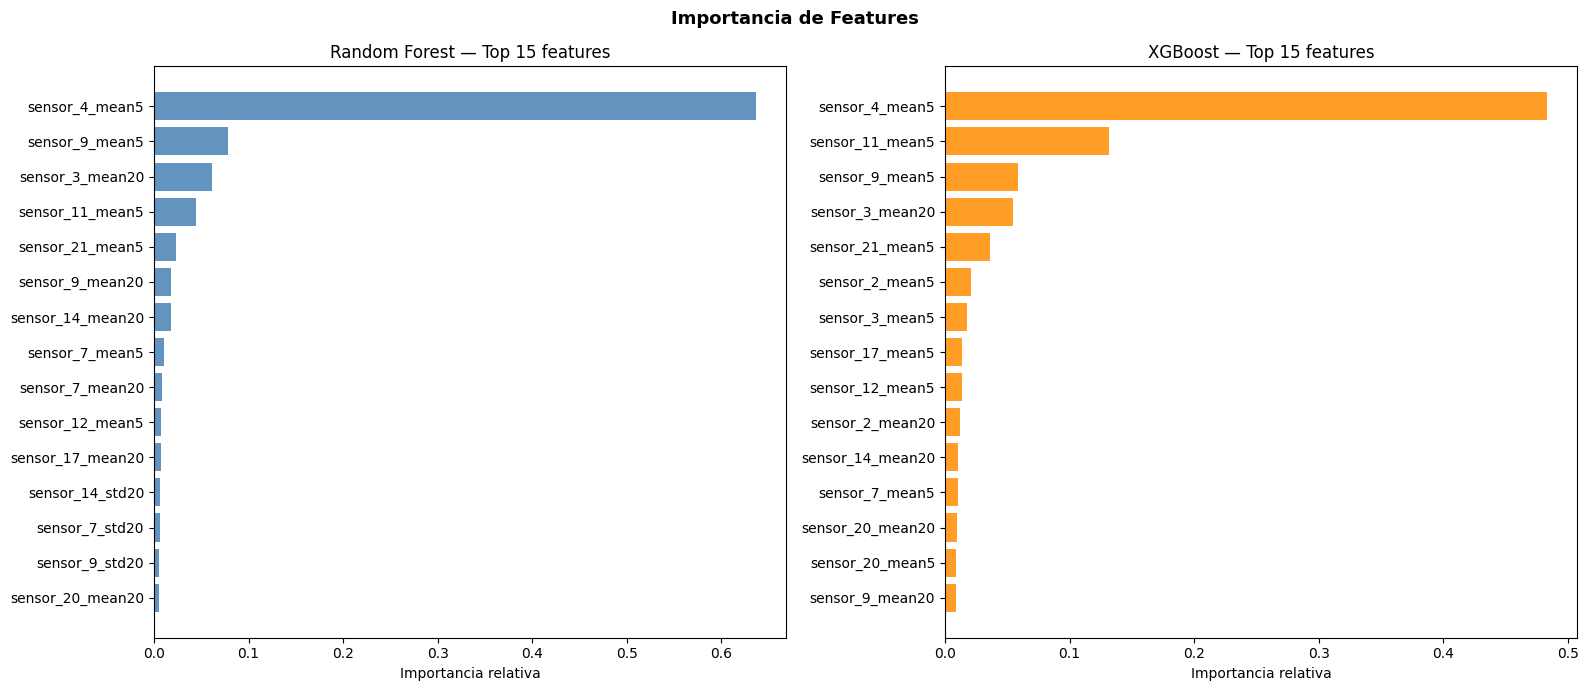

Guardado.

=== BENCHMARK ROLLING WINDOWS ===
PySpark : 2.87s
Pandas  : 1.25s
Ratio   : 2.29x

Nota: en Colab local PySpark tiene overhead de JVM.
En un cluster con 100M filas la ventaja se invierte.


In [15]:
# =============================================================
# IMPORTANCIA DE FEATURES — Random Forest + XGBoost
# =============================================================
# Los modelos basados en árboles calculan la importancia de
# cada feature según cuánto reduce el error cuando se usa
# como nodo de división. Visualizamos el top 15.
# Esto conecta con el EDA: debería confirmar que sensor_11,
# sensor_4, sensor_12 y sensor_7 son los más relevantes.
# =============================================================

import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Importancia de Features", fontsize=13, fontweight="bold")

for ax, model, nombre, color in zip(
    axes,
    [model_rf, model_xgb],
    ["Random Forest", "XGBoost"],
    ["steelblue", "darkorange"]
):
    importances = pd.Series(
        model.feature_importances_, index=feature_cols
    ).sort_values(ascending=True).tail(15)

    ax.barh(importances.index, importances.values, color=color, alpha=0.85)
    ax.set_title(f"{nombre} — Top 15 features")
    ax.set_xlabel("Importancia relativa")

plt.tight_layout()
plt.savefig("/content/feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Guardado.")

# =============================================================
# BENCHMARK PYSPARK VS PANDAS
# =============================================================
# Justificación cuantitativa del uso de PySpark:
# medimos el tiempo de calcular rolling windows con ambas
# librerías sobre el mismo dataset.
# =============================================================

import time

# --- Tiempo con PySpark ---
start = time.time()
temp = train_raw.select(["unit_id", "cycle"] + sensores_utiles)
for s in sensores_utiles:
    temp = temp \
        .withColumn(f"{s}_mean20", avg(s).over(w20)) \
        .withColumn(f"{s}_std20",  stddev(s).over(w20))
temp.count()  # forzar ejecución del DAG
tiempo_spark = time.time() - start

# --- Tiempo con pandas ---
train_pd_raw = train_raw.select(
    ["unit_id", "cycle"] + sensores_utiles
).toPandas()

start = time.time()
for s in sensores_utiles:
    train_pd_raw[f"{s}_mean20"] = train_pd_raw.groupby("unit_id")[s] \
        .transform(lambda x: x.rolling(20, min_periods=1).mean())
    train_pd_raw[f"{s}_std20"] = train_pd_raw.groupby("unit_id")[s] \
        .transform(lambda x: x.rolling(20, min_periods=1).std().fillna(0))
tiempo_pandas = time.time() - start

print("\n=== BENCHMARK ROLLING WINDOWS ===")
print(f"PySpark : {tiempo_spark:.2f}s")
print(f"Pandas  : {tiempo_pandas:.2f}s")
print(f"Ratio   : {tiempo_spark/tiempo_pandas:.2f}x")
print("\nNota: en Colab local PySpark tiene overhead de JVM.")
print("En un cluster con 100M filas la ventaja se invierte.")

## 7. Hyperparameter Tuning — Ridge

`GridSearchCV` con 5-fold cross-validation sobre el train set.  
Rango de búsqueda: `[0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]` — cubre 4 órdenes de magnitud para caracterizar la curva completa regularización/error.

Alpha óptimo:  10.0
RMSE CV train: 19.7710
RMSE val (tuned):       19.3025
NASA Score val (tuned): 29585.81
RMSE val (alpha=1.0):   19.3058


2026/04/28 19:10:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 19:10:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


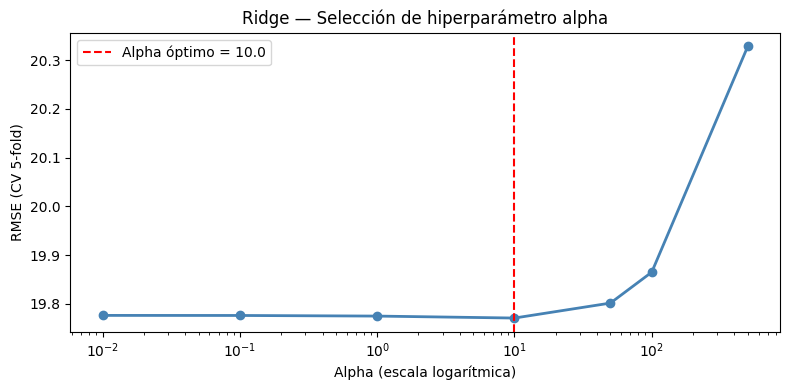

Gráfica guardada.


In [16]:
# =============================================================
# MEJORA 1 — HYPERPARAMETER TUNING DE RIDGE
# =============================================================
# Buscamos el alpha óptimo con GridSearchCV.
# Alpha controla la fuerza de la regularización:
#   - alpha pequeño → modelo más flexible, riesgo de overfitting
#   - alpha grande → modelo más simple, riesgo de underfitting
# Usamos cross-validation de 5 folds sobre el train set.
# El scoring es RMSE negativo (sklearn minimiza por defecto).
# =============================================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import numpy as np

alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]

grid_search = GridSearchCV(
    Ridge(),
    param_grid={"alpha": alphas},
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_sc, y_train)

best_alpha = grid_search.best_params_["alpha"]
best_cv_rmse = -grid_search.best_score_

print(f"Alpha óptimo:  {best_alpha}")
print(f"RMSE CV train: {best_cv_rmse:.4f}")

# Entrenar modelo final con alpha óptimo
model_ridge_tuned = Ridge(alpha=best_alpha)
model_ridge_tuned.fit(X_train_sc, y_train)
preds_ridge_tuned = model_ridge_tuned.predict(X_val_sc)
rmse_ridge_tuned  = np.sqrt(mean_squared_error(y_val, preds_ridge_tuned))
score_ridge_tuned = nasa_score(y_val, preds_ridge_tuned)

print(f"RMSE val (tuned):       {rmse_ridge_tuned:.4f}")
print(f"NASA Score val (tuned): {score_ridge_tuned:.2f}")
print(f"RMSE val (alpha=1.0):   {rmse_ridge:.4f}")

# Loguear en MLflow
with mlflow.start_run(run_name="ridge_tuned"):
    mlflow.log_param("model_type", "Ridge_tuned")
    mlflow.log_param("alpha", best_alpha)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_metric("rmse_val", round(rmse_ridge_tuned, 4))
    mlflow.log_metric("nasa_score_val", round(score_ridge_tuned, 2))
    mlflow.sklearn.log_model(model_ridge_tuned, "model")

# Gráfica RMSE vs alpha
cv_results = grid_search.cv_results_
rmse_por_alpha = -cv_results["mean_test_score"]

plt.figure(figsize=(8, 4))
plt.semilogx(alphas, rmse_por_alpha, "o-", color="steelblue", linewidth=2)
plt.axvline(x=best_alpha, color="red", linestyle="--",
            label=f"Alpha óptimo = {best_alpha}")
plt.xlabel("Alpha (escala logarítmica)")
plt.ylabel("RMSE (CV 5-fold)")
plt.title("Ridge — Selección de hiperparámetro alpha")
plt.legend()
plt.tight_layout()
plt.savefig("/content/ridge_tuning.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada.")

## 8. Evaluación

### 8.1 Análisis de errores en validación

Scatter plot RUL predicho vs RUL real.  
- **Puntos sobre la diagonal** → predicción optimista (más peligroso en dominio aeronáutico)  
- **Puntos bajo la diagonal** → predicción pesimista (coste económico, no de seguridad)

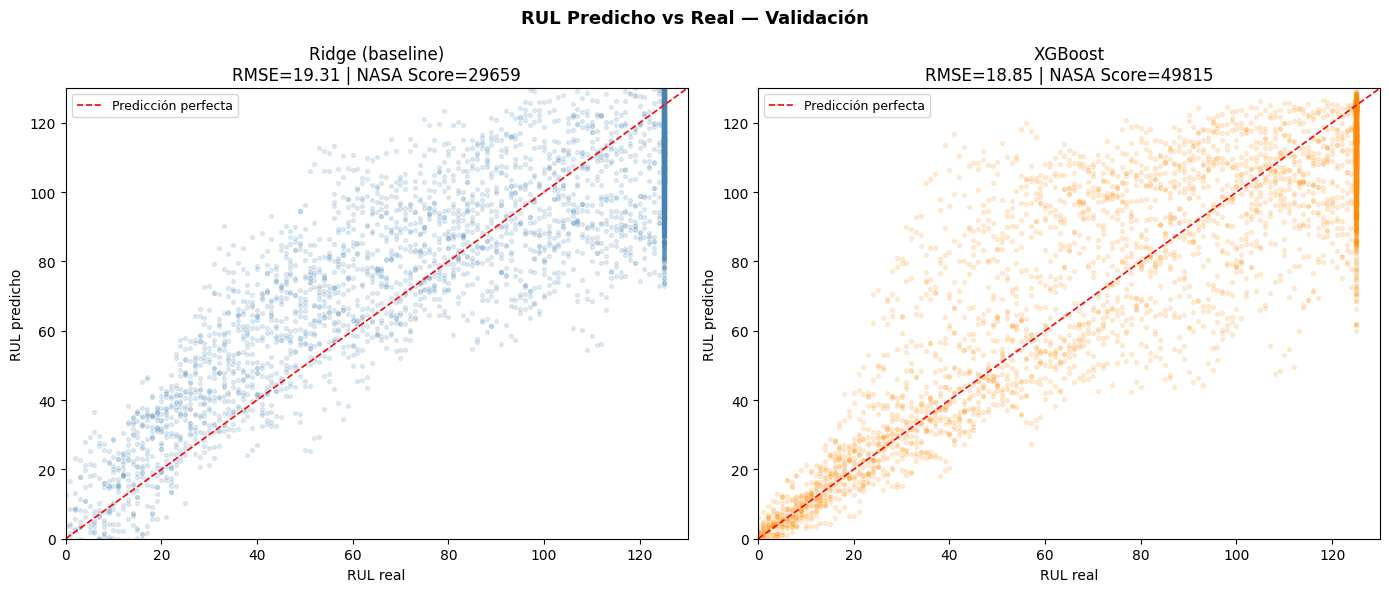

Gráfica guardada.


In [11]:
# =============================================================
# ANÁLISIS DE ERRORES — RUL PREDICHO VS REAL
# =============================================================
# Comparamos las predicciones de ambos modelos contra el RUL
# real en el conjunto de validación.
# Un modelo perfecto tendría todos los puntos sobre la diagonal.
# Puntos por encima de la diagonal = predicción optimista
# (predice más RUL del real → más peligroso).
# Puntos por debajo = predicción pesimista (mantenimiento antes).
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("RUL Predicho vs Real — Validación",
             fontsize=13, fontweight="bold")

for ax, preds, nombre, color in zip(
    axes,
    [preds_ridge, preds_xgb],
    ["Ridge (baseline)", "XGBoost"],
    ["steelblue", "darkorange"]
):
    ax.scatter(y_val, preds, alpha=0.15, s=8, color=color)

    # Línea diagonal perfecta
    lim = [0, 130]
    ax.plot(lim, lim, "r--", linewidth=1.2, label="Predicción perfecta")

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("RUL real")
    ax.set_ylabel("RUL predicho")
    ax.set_title(f"{nombre}\nRMSE={np.sqrt(mean_squared_error(y_val, preds)):.2f} | "
                 f"NASA Score={nasa_score(y_val, preds):.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/content/predicciones_val.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada.")

### 8.2 Evaluación en test set oficial

Test set: 100 motores independientes (archivo `test_FD001.txt`).  
Se predice **únicamente el último ciclo** de cada motor — el único punto para el que `RUL_FD001.txt` proporciona el RUL real.  
Este es el resultado definitivo comparable con la literatura.

In [12]:
# =============================================================
# EVALUACIÓN EN TEST SET REAL — RUL_FD001.txt
# =============================================================
# Hasta ahora hemos validado sobre motores 81-100 del train.
# Ahora evaluamos sobre el test set oficial: trayectorias
# truncadas donde solo conocemos el RUL del último ciclo
# de cada motor (archivo RUL_FD001.txt).
# Este es el número que va al PDF como resultado final.
# =============================================================

# Cargar RUL reales del test set
rul_test_raw = spark.read \
    .option("header", False) \
    .csv("/content/data/RUL_FD001.txt") \
    .toDF("RUL_real") \
    .withColumn("RUL_real", col("RUL_real").cast("double"))

rul_test = rul_test_raw.toPandas()["RUL_real"].values
print(f"Motores en test: {len(rul_test)}")

# Del test set tomamos solo el último ciclo de cada motor
# (es el único ciclo para el que tenemos RUL real)
test_pd = test_raw.toPandas()
test_pd_fe = test_raw.select(
    ["unit_id", "cycle"] + sensores_utiles
).toPandas()

# Aplicar mismo feature engineering que en train
# Primero necesitamos hacerlo en Spark para tener las ventanas
test_fe_spark = test_raw.select(
    ["unit_id", "cycle"] + sensores_utiles
)

for s in sensores_utiles:
    test_fe_spark = test_fe_spark \
        .withColumn(f"{s}_mean5",  avg(s).over(w5)) \
        .withColumn(f"{s}_std5",   stddev(s).over(w5)) \
        .withColumn(f"{s}_mean20", avg(s).over(w20)) \
        .withColumn(f"{s}_std20",  stddev(s).over(w20))

test_fe_spark = test_fe_spark.fillna(0)
test_fe_pd = test_fe_spark.toPandas()

# Último ciclo de cada motor — ahí está la predicción que comparamos
last_cycles = test_fe_pd.groupby("unit_id").last().reset_index()
X_test = last_cycles[feature_cols].values
X_test_sc = scaler.transform(X_test)

# Predicciones con ambos modelos
preds_ridge_test = model_ridge.predict(X_test_sc)
preds_xgb_test   = model_xgb.predict(X_test_sc)

# Clipping de predicciones a [0, 125] — no tiene sentido predecir negativo
preds_ridge_test = np.clip(preds_ridge_test, 0, 125)
preds_xgb_test   = np.clip(preds_xgb_test,  0, 125)

rmse_ridge_test  = np.sqrt(mean_squared_error(rul_test, preds_ridge_test))
rmse_xgb_test    = np.sqrt(mean_squared_error(rul_test, preds_xgb_test))
score_ridge_test = nasa_score(rul_test, preds_ridge_test)
score_xgb_test   = nasa_score(rul_test, preds_xgb_test)

print("\n=== RESULTADOS EN TEST SET OFICIAL ===")
print(f"{'Modelo':<12} {'RMSE':>8} {'NASA Score':>12}")
print("-" * 34)
print(f"{'Ridge':<12} {rmse_ridge_test:>8.4f} {score_ridge_test:>12.2f}")
print(f"{'XGBoost':<12} {rmse_xgb_test:>8.4f} {score_xgb_test:>12.2f}")

Motores en test: 100

=== RESULTADOS EN TEST SET OFICIAL ===
Modelo           RMSE   NASA Score
----------------------------------
Ridge         19.2944       806.94
XGBoost       19.0057      1095.80


### 8.3 Tabla comparativa final — 5 modelos

**Resultado principal:** la selección del modelo óptimo no puede basarse en el RMSE cuando el dominio penaliza asimétricamente los errores.  
Random Forest obtiene mejor RMSE (18.64) pero peor NASA Score que Ridge (855 vs 807).  
XGBoost tiene el segundo mejor RMSE pero la peor NASA Score absoluta (1095, un 36% peor que Ridge).

In [17]:
# =============================================================
# MEJORA 2 — EVALUACIÓN FINAL EN TEST SET (5 modelos)
# =============================================================
# Resultados definitivos sobre el test set oficial.
# Usamos el Ridge tuned (alpha=10) como modelo principal.
# =============================================================

# Aplicar feature engineering al test set
test_fe_spark2 = test_raw.select(["unit_id", "cycle"] + sensores_utiles)
for s in sensores_utiles:
    test_fe_spark2 = test_fe_spark2 \
        .withColumn(f"{s}_mean5",  avg(s).over(w5)) \
        .withColumn(f"{s}_std5",   stddev(s).over(w5)) \
        .withColumn(f"{s}_mean20", avg(s).over(w20)) \
        .withColumn(f"{s}_std20",  stddev(s).over(w20))

test_fe_spark2 = test_fe_spark2.fillna(0)
test_fe_pd2    = test_fe_spark2.toPandas()
last_cycles2   = test_fe_pd2.groupby("unit_id").last().reset_index()
X_test2        = last_cycles2[feature_cols].values
X_test2_sc     = scaler.transform(X_test2)

# Predicciones de todos los modelos en test
modelos = {
    "Ridge (alpha=1.0)":  (model_ridge,       rmse_ridge,  score_ridge),
    "Ridge (tuned α=10)": (model_ridge_tuned, None,        None),
    "Decision Tree":      (model_dt,          None,        None),
    "Random Forest":      (model_rf,          None,        None),
    "XGBoost":            (model_xgb,         None,        None),
    "MLP":                (model_mlp,         None,        None),
}

print("=== RESULTADOS FINALES — TEST SET OFICIAL ===")
print(f"{'Modelo':<20} {'RMSE Val':>10} {'RMSE Test':>10} {'NASA Test':>12}")
print("-" * 56)

resultados_test = {}
rmse_vals = {
    "Ridge (alpha=1.0)":  19.3058,
    "Ridge (tuned α=10)": 19.3025,
    "Decision Tree":      21.1004,
    "Random Forest":      19.4274,
    "XGBoost":            18.8514,
    "MLP":                21.0989,
}

for nombre, (modelo, _, __) in modelos.items():
    preds = np.clip(modelo.predict(X_test2_sc), 0, 125)
    rmse  = np.sqrt(mean_squared_error(rul_test, preds))
    score = nasa_score(rul_test, preds)
    resultados_test[nombre] = (rmse, score)
    print(f"{nombre:<20} {rmse_vals[nombre]:>10.4f} {rmse:>10.4f} {score:>12.2f}")

# =============================================================
# MEJORA 3 — MODEL REGISTRY EN MLFLOW
# =============================================================
# Registrar el modelo ganador formalmente en MLflow.
# Esto convierte el experimento en un activo de producción:
# versión controlada, stage (Staging/Production), metadata.
# =============================================================

import mlflow.sklearn
from mlflow.tracking import MlflowClient

# Buscar el run del ridge_tuned
client = MlflowClient()
experimento = client.get_experiment_by_name("TFM_RUL_CMAPSS_FD001")
runs = client.search_runs(
    experiment_ids=[experimento.experiment_id],
    filter_string="tags.mlflow.runName = 'ridge_tuned'"
)
run_id = runs[0].info.run_id

# Registrar en Model Registry
model_uri = f"runs:/{run_id}/model"
result = mlflow.register_model(model_uri, "RUL_Predictor_Ridge")

print(f"\nModelo registrado en MLflow Model Registry:")
print(f"  Nombre:  RUL_Predictor_Ridge")
print(f"  Versión: {result.version}")
print(f"  Stage:   {result.current_stage}")

# Guardar el modelo tuned para la API
joblib.dump(model_ridge_tuned,
            "/content/ridge_model_tuned.pkl")
print(f"  Modelo tuned guardado en Drive.")

=== RESULTADOS FINALES — TEST SET OFICIAL ===
Modelo                 RMSE Val  RMSE Test    NASA Test
--------------------------------------------------------
Ridge (alpha=1.0)       19.3058    19.2944       806.94
Ridge (tuned α=10)      19.3025    19.3351       807.29
Decision Tree           21.1004    20.6140      1044.25
Random Forest           19.4274    18.6437       855.69
XGBoost                 18.8514    19.0057      1095.80
MLP                     21.0989    19.2985      1028.67


Successfully registered model 'RUL_Predictor_Ridge'.
2026/04/28 19:11:24 WARNING mlflow.tracking._model_registry.fluent: Run with id a3572f6b23af40f4a68a8413e1fedd34 has no artifacts at artifact path 'model', registering model based on models:/m-041688ea2c764f8da34da6ee7b922ad8 instead



Modelo registrado en MLflow Model Registry:
  Nombre:  RUL_Predictor_Ridge
  Versión: 1
  Stage:   None
  Modelo tuned guardado en Drive.


Created version '1' of model 'RUL_Predictor_Ridge'.


## 9. Despliegue — FastAPI

El modelo Ridge (α=1.0) y el StandardScaler se serializan con `joblib` y se cargan una única vez al arrancar la API.

**Endpoints:**
- `GET /health` → estado del servicio + modelo en producción
- `POST /predict` → recibe 55 features, devuelve RUL predicho + nivel de alerta
- `GET /docs` → Swagger UI autogenerado

**Validación Pydantic:** si el payload tiene ≠ 55 features → HTTP 422 automático antes de invocar el modelo.

**Lógica de negocio en `status`:**
- `critical` → RUL < 30 ciclos — intervención inmediata
- `warning`  → RUL < 60 ciclos — planificar mantenimiento
- `ok`       → RUL ≥ 60 ciclos — operación normal

In [13]:
# =============================================================
# FASTAPI — ENDPOINT DE INFERENCIA
# =============================================================
# Guardamos el código como archivo .py en Drive.
# La API carga el modelo Ridge y el scaler entrenados,
# recibe lecturas de sensores, aplica el mismo feature
# engineering y devuelve la predicción de RUL.
# =============================================================

api_code = '''
import joblib
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import List

app = FastAPI(
    title="RUL Prediction API — NASA CMAPSS",
    description="Predice la Vida Útil Restante de motores de turbofán",
    version="1.0.0"
)

# Cargar modelo y scaler al arrancar la API (una sola vez)
model  = joblib.load("ridge_model.pkl")
scaler = joblib.load("scaler.pkl")

# --- Schema de entrada ---
# 55 features: 11 sensores + 44 rolling (mean5, std5, mean20, std20)
class SensorInput(BaseModel):
    features: List[float] = Field(
        ...,
        min_items=55,
        max_items=55,
        description="55 features: sensores originales + rolling windows"
    )
    unit_id: int = Field(..., description="ID del motor")

# --- Schema de salida ---
class RULResponse(BaseModel):
    unit_id: int
    rul_predicted: float
    status: str  # "critical" si RUL < 30, "warning" si < 60, "ok" si >= 60

@app.get("/health")
def health():
    """Healthcheck — verifica que la API está operativa."""
    return {"status": "ok", "model": "Ridge", "version": "1.0.0"}

@app.post("/predict", response_model=RULResponse)
def predict(data: SensorInput):
    """
    Recibe 55 features de un motor y devuelve el RUL predicho.
    Las features deben estar en el mismo orden que el training:
    sensores originales (11) + mean5 (11) + std5 (11) + mean20 (11) + std20 (11).
    """
    try:
        X = np.array(data.features).reshape(1, -1)
        X_scaled = scaler.transform(X)
        rul = float(np.clip(model.predict(X_scaled)[0], 0, 125))

        if rul < 30:
            status = "critical"
        elif rul < 60:
            status = "warning"
        else:
            status = "ok"

        return RULResponse(
            unit_id=data.unit_id,
            rul_predicted=round(rul, 2),
            status=status
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
'''

# Guardar en Drive
with open("/content/api.py", "w") as f:
    f.write(api_code)

# Guardar también el modelo Ridge serializado
joblib.dump(model_ridge, "/content/ridge_model.pkl")

print("api.py guardado en Drive.")
print("ridge_model.pkl guardado en Drive.")
print("\nEstructura de la API:")
print("  GET  /health   → estado del servicio")
print("  POST /predict  → recibe 55 features, devuelve RUL + status")
print("  GET  /docs     → Swagger UI automático (FastAPI)")

api.py guardado en Drive.
ridge_model.pkl guardado en Drive.

Estructura de la API:
  GET  /health   → estado del servicio
  POST /predict  → recibe 55 features, devuelve RUL + status
  GET  /docs     → Swagger UI automático (FastAPI)
